# 03C - Transcript Pretrained Text Multi-Task SER 5-Fold + 10-Fold

Notebook này tạo nhánh **transcript pretrained text** cho cùng bài toán IEMOCAP:

```text
Transcript
  -> pretrained text backbone BERT/DeBERTa/RoBERTa
  -> attentive pooling
  -> shared embedding
  -> two heads: emotion classification + VAD regression
  -> fusion_features cho notebook 04
```

03C không thay thế 03A/03B. Nó trả lời câu hỏi: **chỉ dùng transcript thì model học được bao nhiêu tín hiệu cảm xúc**, và liệu text embedding có bổ sung được cho speech/acoustic trong bước fusion hay không.

> Kaggle note: notebook mặc định dùng `roberta-base` để tránh lỗi/kẹt tải `spm.model` thường gặp với DeBERTaV3. Nếu môi trường ổn định, có thể set `TEXT_MODEL_NAME=microsoft/deberta-v3-base` để thử lại DeBERTaV3.


<!-- AUTO-FULL-RUN-GUARD -->
## Chế độ chạy full

Notebook này mặc định chạy full 5-fold + 10-fold cho nhánh transcript:

```text
RUN_MODE=full
RUN_PROTOCOLS=5fold_session,10fold_speaker
MAX_FOLDS=0
EVAL_TRAIN_SPLIT=1
```

Nếu muốn notebook dừng ngay khi cấu hình chưa phải full, set:

```text
REQUIRE_FULL_RUN=1
```

03C không cần raw audio. Nó chỉ cần metadata/splits/text-ready từ output 02.


<!-- AUTO-03ABC-REFERENCE -->
## Nghiên cứu tham khảo cho nhánh transcript

| Paper / model | Input | Split / task | Kiến trúc sơ bộ | Kết quả tham khảo | Ý nghĩa với 03C |
|---|---|---|---|---|---|
| [Ispas et al., 2024 - Multi-task, Multi-modal categorical + dimensional emotion](https://arxiv.org/abs/2401.00536) | Audio + transcript | IEMOCAP 10-fold speaker guideline | HuBERT-large + DeBERTaV3-large, self-attention, bridge tokens, multi-task heads | UAR 74.68, WAR 74.69, Valence CCC 0.738, Arousal CCC 0.685 | Cho thấy transcript backbone rất đáng dùng trong multi-task/fusion |
| [Zhao et al., 2022 - Multi-level Fusion of Wav2Vec2 and BERT](https://arxiv.org/abs/2207.04697) | Speech + BERT text | IEMOCAP multimodal SER | wav2vec2 + BERT, co-attention/late fusion, multi-granularity speech embeddings | Paper báo cáo vượt baseline UA trên IEMOCAP | Cho thấy text pretrained model thường tăng kết quả khi fusion với speech |
| [Padi et al., 2022 - Transfer learning from speaker recognition and BERT](https://arxiv.org/abs/2202.08974) | Audio + BERT text | IEMOCAP emotion recognition | ResNet audio transfer + fine-tuned BERT text + late fusion | Paper cho thấy audio/text đều cải thiện và fusion tốt hơn | Gợi ý train text branch riêng rồi late fusion là hướng hợp lý |
| [Siriwardhana et al., 2020 - jointly fine-tuning BERT-like SSL models](https://arxiv.org/abs/2008.06682) | Speech + text | IEMOCAP / CMU-MOSEI / CMU-MOSI | modality-specific SSL backbones, joint fine-tuning/fusion | Báo cáo SSL text/speech giúp multimodal SER | Củng cố việc dùng pretrained transcript branch |

Lưu ý: các kết quả paper không luôn so sánh 1-1 vì khác label mapping, số mẫu, split, và có/không dùng visual/audio. Trong project này, 03C phải được so sánh trực tiếp bằng **cùng 5-fold và 10-fold** với 03A/03B.

## Kiến trúc 03C

```mermaid
flowchart LR
    A["Transcript text"] --> B["Tokenizer"]
    B --> C["Pretrained text backbone<br/>DeBERTa/BERT/RoBERTa"]
    C --> D["CLS pooling"]
    C --> E["Masked mean pooling"]
    C --> F["Attentive pooling"]
    D --> G["Concatenate"]
    E --> G
    F --> G
    G --> H["Shared projection"]
    H --> I["Emotion head<br/>4-class softmax"]
    H --> J["VAD regression head<br/>valence/arousal/dominance"]
    H --> K["Fusion embedding for notebook 04"]
```

Text branch có ưu điểm là bắt nội dung ngữ nghĩa: lời nói có từ ngữ buồn, tức giận, vui, phủ định, cường điệu. Nhưng nó không biết giọng nói có năng lượng cao/thấp, pitch hay pause, nên 03C nên được xem là nhánh bổ sung cho 03A/03B.

## Metric và loss

Emotion classification dùng:

$$
\operatorname{WA} = \frac{\sum_i \mathbf{1}(\hat{y}_i=y_i)}{N}
$$

$$
\operatorname{UAR} = \frac{1}{C}\sum_{c=1}^{C}\frac{TP_c}{TP_c+FN_c}
$$

VAD regression dùng CCC:

$$
\rho_c = \frac{2\sigma_{xy}}{\sigma_x^2+\sigma_y^2+(\mu_x-\mu_y)^2}
$$

Loss multi-task:

$$
\mathcal{L}
= \lambda_{CE}\mathcal{L}_{CE}
+ \lambda_{MSE}\mathcal{L}_{MSE}
+ \lambda_{CCC}(1-\operatorname{CCC})
$$

Trong notebook, VAD được chuẩn hóa từ thang IEMOCAP 1-5 về 0-1 khi train, rồi đổi lại 1-5 khi tính MAE/RMSE/CCC để dễ đọc.

## Input cần upload

Notebook 03C cần output từ notebook 01/02:

```text
metadata/iemocap_4class_avd_metadata.csv
splits/iemocap_5fold_session_long.csv
splits/iemocap_10fold_speaker_long.csv
text/text_ready_metadata.csv        # nếu có từ notebook 02
text/text_folds_long.csv            # nếu có từ notebook 02
```

Nếu không có `text_ready_metadata.csv`, notebook sẽ tự dùng `transcript` trong metadata/split. Không cần raw audio.

In [1]:
import os
import sys
import json
import time
import math
import zipfile
import random
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

INSTALL_DEPS = os.getenv("INSTALL_DEPS", "1") == "1"
if INSTALL_DEPS:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "-U",
        "transformers==4.51.3",
        "tokenizers==0.21.1",
        "huggingface_hub==0.30.2",
        "sentencepiece",
        "accelerate",
        "safetensors",
    ])

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    plt = None
    sns = None

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("CUDA devices:", torch.cuda.device_count())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 145.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 378.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB 312.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 388.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 359.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 404.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.30.2 which is incompatible.


DEVICE: cuda
CUDA devices: 2


In [2]:
LOCAL_PROJECT = Path(r"D:\UTE\Speech Programming\Speech Project")

def unique_existing(paths):
    out, seen = [], set()
    for item in paths:
        if not item:
            continue
        path = Path(item)
        if path.exists():
            key = str(path.resolve()).lower()
            if key not in seen:
                seen.add(key)
                out.append(path.resolve())
    return out

def search_roots():
    roots = [
        os.getenv("IEMOCAP_DATA_DIR"),
        os.getenv("KAGGLE_INPUT_DIR"),
        Path.cwd(),
        Path.cwd().parent,
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        LOCAL_PROJECT / "06_w2v_based_models" / "data",
        LOCAL_PROJECT / "06_w2v_based_models",
    ]
    return unique_existing(roots)

def find_named_file(filename, env_var=None, description=None, required=True):
    if env_var and os.getenv(env_var):
        candidate = Path(os.getenv(env_var))
        if candidate.exists():
            return candidate.resolve()
    candidates = []
    for root in search_roots():
        for rel in [
            filename,
            Path("data") / filename,
            Path("metadata") / filename,
            Path("splits") / filename,
            Path("text") / filename,
            Path("output") / filename,
            Path("output") / "metadata" / filename,
            Path("output") / "splits" / filename,
            Path("output") / "text" / filename,
        ]:
            candidates.append(root / rel)
        try:
            candidates.extend(root.rglob(filename))
        except Exception:
            pass
    existing = sorted({p.resolve() for p in candidates if p.exists() and p.is_file()}, key=lambda p: (len(p.parts), str(p).lower()))
    if existing:
        return existing[0]
    if required:
        roots_text = "\n".join(f"- {r}" for r in search_roots())
        raise FileNotFoundError(f"Không tìm thấy {description or filename}. Đã quét:\n{roots_text}")
    return None

TEXT_READY_PATH = find_named_file("text_ready_metadata.csv", env_var="IEMOCAP_TEXT_READY_PATH", required=False)
TEXT_FOLDS_PATH = find_named_file("text_folds_long.csv", env_var="IEMOCAP_TEXT_FOLDS_PATH", required=False)
METADATA_PATH = find_named_file("iemocap_4class_avd_metadata.csv", env_var="IEMOCAP_METADATA_PATH", description="metadata IEMOCAP")
SPLIT_5FOLD_PATH = find_named_file("iemocap_5fold_session_long.csv", env_var="IEMOCAP_5FOLD_SPLIT_PATH", description="5-fold split")
SPLIT_10FOLD_PATH = find_named_file("iemocap_10fold_speaker_long.csv", env_var="IEMOCAP_10FOLD_SPLIT_PATH", description="10-fold split")

print("TEXT_READY_PATH:", TEXT_READY_PATH)
print("TEXT_FOLDS_PATH:", TEXT_FOLDS_PATH)
print("METADATA_PATH:", METADATA_PATH)
print("SPLIT_5FOLD_PATH:", SPLIT_5FOLD_PATH)
print("SPLIT_10FOLD_PATH:", SPLIT_10FOLD_PATH)

TEXT_READY_PATH: None
TEXT_FOLDS_PATH: None
METADATA_PATH: /kaggle/input/datasets/quanghuy225/output01/output/metadata/iemocap_4class_avd_metadata.csv
SPLIT_5FOLD_PATH: /kaggle/input/datasets/quanghuy225/output01/output/splits/iemocap_5fold_session_long.csv
SPLIT_10FOLD_PATH: /kaggle/input/datasets/quanghuy225/output01/output/splits/iemocap_10fold_speaker_long.csv


In [3]:
RUN_MODE = os.getenv("RUN_MODE", "full").strip().lower()
IS_TUNE_MODE = RUN_MODE != "full"

TEXT_MODEL_NAME = os.getenv("TEXT_MODEL_NAME", "roberta-base")
TEXT_MODEL_PATH = os.getenv("TEXT_MODEL_PATH", "").strip()
ALLOW_HF_DOWNLOAD = os.getenv("ALLOW_HF_DOWNLOAD", "0") == "1"
TEXT_TUNE_LAST_N = int(os.getenv("TEXT_TUNE_LAST_N", "2"))
MAX_LENGTH = int(os.getenv("MAX_LENGTH", "96"))
EPOCHS = int(os.getenv("EPOCHS", "6" if not IS_TUNE_MODE else "3"))
PATIENCE = int(os.getenv("PATIENCE", "3"))
MIN_DELTA = float(os.getenv("MIN_DELTA", "0.001"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "12"))
GRAD_ACCUM = int(os.getenv("GRAD_ACCUM", "1"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "0"))

LR_BACKBONE = float(os.getenv("LR_BACKBONE", "1.5e-5"))
LR_HEAD = float(os.getenv("LR_HEAD", "3e-4"))
WARMUP_RATIO = float(os.getenv("WARMUP_RATIO", "0.08"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "0.01"))
DROPOUT = float(os.getenv("DROPOUT", "0.25"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.05"))
USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_AMP = os.getenv("USE_AMP", "1") == "1"
USE_DATA_PARALLEL = os.getenv("USE_DATA_PARALLEL", "1") == "1" and torch.cuda.device_count() > 1

RUN_PROTOCOLS = [x.strip() for x in os.getenv("RUN_PROTOCOLS", "5fold_session,10fold_speaker" if not IS_TUNE_MODE else "5fold_session").split(",") if x.strip()]
MAX_FOLDS = int(os.getenv("MAX_FOLDS", "0" if not IS_TUNE_MODE else "1"))
EVAL_TRAIN_SPLIT = os.getenv("EVAL_TRAIN_SPLIT", "1" if not IS_TUNE_MODE else "0") == "1"


REQUIRE_FULL_RUN = os.getenv("REQUIRE_FULL_RUN", "0") == "1"
if REQUIRE_FULL_RUN:
    expected_protocols = {"5fold_session", "10fold_speaker"}
    if RUN_MODE != "full" or MAX_FOLDS != 0 or set(RUN_PROTOCOLS) != expected_protocols or not EVAL_TRAIN_SPLIT:
        raise ValueError(
            "REQUIRE_FULL_RUN=1 nhưng cấu hình chưa phải full. "
            f"RUN_MODE={RUN_MODE}, MAX_FOLDS={MAX_FOLDS}, RUN_PROTOCOLS={RUN_PROTOCOLS}, "
            f"EVAL_TRAIN_SPLIT={EVAL_TRAIN_SPLIT}. "
            "Cần RUN_MODE=full, MAX_FOLDS=0, RUN_PROTOCOLS=5fold_session,10fold_speaker, EVAL_TRAIN_SPLIT=1."
        )
SEED = int(os.getenv("SEED", "42"))

OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output_03c_transcript_text_branch")).resolve()
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
FUSION_DIR = OUTPUT_DIR / "fusion_features"
FIGURE_DIR = OUTPUT_DIR / "figures"
for p in [MODEL_DIR, REPORT_DIR, FUSION_DIR, FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

LIVE_LOG_PATH = REPORT_DIR / "03C_live_training_log.txt"
LOG_EVERY_STEPS = int(os.getenv("LOG_EVERY_STEPS", "25"))

def live_log(message):
    stamp = time.strftime("%Y-%m-%d %H:%M:%S")
    text = f"[{stamp}] {message}"
    print(text, flush=True)
    with LIVE_LOG_PATH.open("a", encoding="utf-8") as f:
        f.write(text + "\n")

print({
    "RUN_MODE": RUN_MODE,
    "TEXT_MODEL_NAME": TEXT_MODEL_NAME,
    "TEXT_MODEL_PATH": TEXT_MODEL_PATH,
    "ALLOW_HF_DOWNLOAD": ALLOW_HF_DOWNLOAD,
    "TEXT_TUNE_LAST_N": TEXT_TUNE_LAST_N,
    "MAX_LENGTH": MAX_LENGTH,
    "EPOCHS": EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "LR_BACKBONE": LR_BACKBONE,
    "LR_HEAD": LR_HEAD,
    "RUN_PROTOCOLS": RUN_PROTOCOLS,
    "MAX_FOLDS": MAX_FOLDS,
    "USE_DATA_PARALLEL": USE_DATA_PARALLEL,
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "LOG_EVERY_STEPS": LOG_EVERY_STEPS,
})
def maybe_extract_model_zips_03c():
    extract_dir = Path("extracted_03c_models")
    extract_dir.mkdir(parents=True, exist_ok=True)
    for root in search_roots():
        try:
            zips = list(root.rglob("*.zip"))
        except Exception:
            continue
        for z in zips:
            lname = z.name.lower()
            if not any(k in lname for k in ["roberta", "deberta", "text", "pretrained", "huggingface", "hf-model"]):
                continue
            target = extract_dir / z.stem
            marker = target / ".extracted"
            if marker.exists():
                continue
            try:
                target.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(z, "r") as zipf:
                    zipf.extractall(target)
                marker.write_text("ok", encoding="utf-8")
                live_log(f"Extracted local text model zip: {z}")
            except Exception as exc:
                live_log(f"Không giải nén được text model zip {z}: {exc}")

def _norm_model_name(value):
    return str(value).lower().replace("\\", "/").replace("_", "-").replace(".", "-")

def _looks_like_hf_text_model(path):
    path = Path(path)
    if not path.is_dir():
        return False
    has_config = (path / "config.json").exists()
    has_weight = any((path / name).exists() for name in ["model.safetensors", "pytorch_model.bin"])
    has_tokenizer = any((path / name).exists() for name in [
        "tokenizer.json", "vocab.json", "vocab.txt", "merges.txt", "spm.model", "sentencepiece.bpe.model"
    ])
    return has_config and has_weight and has_tokenizer

def find_local_text_model(model_name):
    maybe_extract_model_zips_03c()
    if TEXT_MODEL_PATH:
        p = Path(TEXT_MODEL_PATH)
        if _looks_like_hf_text_model(p):
            return p.resolve()
        raise FileNotFoundError(
            f"TEXT_MODEL_PATH không hợp lệ: {p}. Cần folder Hugging Face có config.json, weight file và tokenizer."
        )
    wanted = _norm_model_name(model_name).split("/")[-1]
    candidates = []
    for root in search_roots() + [Path("extracted_03c_models")]:
        try:
            for cfg in root.rglob("config.json"):
                folder = cfg.parent
                if _looks_like_hf_text_model(folder):
                    score = 0 if wanted in _norm_model_name(folder) else 1
                    candidates.append((score, len(folder.parts), str(folder).lower(), folder.resolve()))
        except Exception:
            continue
    if candidates:
        return sorted(candidates)[0][-1]
    return None

TEXT_MODEL_SOURCE = find_local_text_model(TEXT_MODEL_NAME)
if TEXT_MODEL_SOURCE is None:
    if not ALLOW_HF_DOWNLOAD:
        roots = "\n".join(f"- {r}" for r in search_roots())
        raise FileNotFoundError(
            "03C không tìm thấy local text model. Notebook chặn tải online mặc định để tránh kẹt 0.00/499M.\n"
            "Hãy upload roberta-base-kaggle.zip vào Kaggle Input, hoặc set TEXT_MODEL_PATH tới folder model.\n"
            "Nếu vẫn muốn tải online, set ALLOW_HF_DOWNLOAD=1.\n\n"
            f"Đã quét:\n{roots}"
        )
    TEXT_MODEL_SOURCE = TEXT_MODEL_NAME
else:
    TEXT_MODEL_SOURCE = str(TEXT_MODEL_SOURCE)

live_log("03C configuration is ready.")
live_log(f"TEXT_MODEL_SOURCE={TEXT_MODEL_SOURCE}")
live_log(f"ALLOW_HF_DOWNLOAD={ALLOW_HF_DOWNLOAD}")
live_log(f"TEXT_TUNE_LAST_N={TEXT_TUNE_LAST_N}")

{'RUN_MODE': 'full', 'TEXT_MODEL_NAME': 'roberta-base', 'TEXT_MODEL_PATH': '', 'ALLOW_HF_DOWNLOAD': False, 'TEXT_TUNE_LAST_N': 2, 'MAX_LENGTH': 96, 'EPOCHS': 6, 'BATCH_SIZE': 12, 'LR_BACKBONE': 1.5e-05, 'LR_HEAD': 0.0003, 'RUN_PROTOCOLS': ['5fold_session', '10fold_speaker'], 'MAX_FOLDS': 0, 'USE_DATA_PARALLEL': True, 'OUTPUT_DIR': '/kaggle/working/output_03c_transcript_text_branch', 'LOG_EVERY_STEPS': 25}
[2026-07-14 10:47:56] 03C configuration is ready.
[2026-07-14 10:47:56] TEXT_MODEL_SOURCE=/kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle
[2026-07-14 10:47:56] ALLOW_HF_DOWNLOAD=False
[2026-07-14 10:47:56] TEXT_TUNE_LAST_N=2


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def normalize_split_names(df):
    df = df.copy()
    df["split"] = df["split"].replace({"validation": "val"})
    return df

metadata = pd.read_csv(TEXT_READY_PATH if TEXT_READY_PATH is not None else METADATA_PATH)
split_5fold = normalize_split_names(pd.read_csv(SPLIT_5FOLD_PATH))
split_10fold = normalize_split_names(pd.read_csv(SPLIT_10FOLD_PATH))

if "transcript" not in metadata.columns:
    raise ValueError("Metadata/text_ready cần có cột transcript để chạy 03C.")

metadata["train_sample_id"] = metadata["train_sample_id"].astype(str)
metadata["utterance_id"] = metadata["utterance_id"].astype(str)
metadata["transcript"] = metadata["transcript"].fillna("").astype(str)
metadata["emotion_id"] = metadata["emotion_id"].astype(int)
for col in ["valence", "arousal", "dominance"]:
    metadata[col] = pd.to_numeric(metadata[col], errors="coerce")

EXPECTED_ROWS = int(os.getenv("EXPECTED_IEMOCAP_4CLASS_ROWS", "5531"))
if len(metadata) != EXPECTED_ROWS:
    raise ValueError(f"Metadata đang có {len(metadata):,} mẫu, cần bản 4-class consensus {EXPECTED_ROWS:,} mẫu.")

def prepare_split(split_df):
    split_df = split_df.copy()
    split_df["train_sample_id"] = split_df["train_sample_id"].astype(str)
    keep_cols = ["train_sample_id", "utterance_id", "transcript", "emotion_4class", "emotion_id", "valence", "arousal", "dominance", "session", "speaker_id"]
    meta_small = metadata[[c for c in keep_cols if c in metadata.columns]].drop_duplicates("train_sample_id")
    if "transcript" not in split_df.columns:
        split_df = split_df.merge(meta_small, on="train_sample_id", how="left", suffixes=("", "_meta"))
    else:
        split_df["transcript"] = split_df["transcript"].fillna("")
    for col in ["utterance_id", "emotion_4class", "emotion_id", "valence", "arousal", "dominance", "session", "speaker_id"]:
        if col not in split_df.columns and col in meta_small.columns:
            split_df = split_df.merge(meta_small[["train_sample_id", col]], on="train_sample_id", how="left")
    split_df["transcript"] = split_df["transcript"].fillna("").astype(str)
    split_df["emotion_id"] = split_df["emotion_id"].astype(int)
    return split_df

split_5fold = prepare_split(split_5fold)
split_10fold = prepare_split(split_10fold)

for name, df, n_folds in [("5fold", split_5fold, 5), ("10fold", split_10fold, 10)]:
    split_values = set(df["split"].unique())
    if split_values != {"train", "val", "test"}:
        raise ValueError(f"{name} split phải là train/val/test, hiện có {split_values}")
    if df["fold"].nunique() != n_folds:
        raise ValueError(f"{name} cần {n_folds} folds, hiện có {df['fold'].nunique()}")

display(metadata[["train_sample_id", "utterance_id", "transcript", "emotion_4class", "valence", "arousal", "dominance"]].head())
display(metadata["emotion_4class"].value_counts().rename_axis("emotion").reset_index(name="count"))

,train_sample_id,utterance_id,transcript,emotion_4class,valence,arousal,dominance
0,iemocap_train_00000,Ses01F_impro01_F000,Excuse me.,neutral,2.5,2.5,2.5
1,iemocap_train_00001,Ses01F_impro01_F001,Yeah.,neutral,2.5,2.5,2.5
2,iemocap_train_00002,Ses01F_impro01_F002,Is there a problem?,neutral,2.5,2.5,2.5
3,iemocap_train_00003,Ses01F_impro01_F005,Well what's the problem? Let me change it.,neutral,2.5,3.5,2.0
4,iemocap_train_00004,Ses01F_impro01_F012,That's out of control.,angry,2.0,3.5,3.5


,emotion,count
0,neutral,1708
1,happy,1636
2,angry,1103
3,sad,1084


char_len                                              word_len                                          
                  count   mean    std  min   25%   50%    75%    max    count   mean    std  min  25%  50%    75%   max
emotion_4class                                                                                                         
angry            1103.0  64.18  53.06  3.0  26.0  48.0  90.00  450.0   1103.0  12.64  10.56  1.0  5.0  9.0  17.00  91.0
happy            1636.0  62.07  55.29  3.0  24.0  44.0  85.00  537.0   1636.0  11.96  10.68  1.0  5.0  8.0  16.25  98.0
neutral          1708.0  51.70  46.25  3.0  19.0  39.0  70.25  344.0   1708.0  10.13   8.98  1.0  4.0  8.0  14.00  66.0
sad              1084.0  58.67  54.98  3.0  20.0  42.0  79.00  433.0   1084.0  11.87  11.13  1.0  4.0  9.0  16.00  84.0

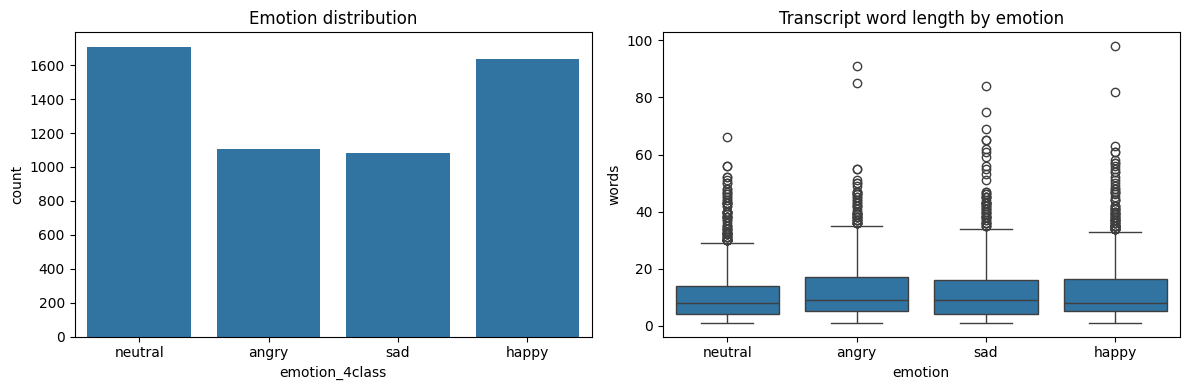

Saved: /kaggle/working/output_03c_transcript_text_branch/figures/transcript_dataset_overview.png


In [5]:
text_stats = metadata.assign(
    char_len=metadata["transcript"].str.len(),
    word_len=metadata["transcript"].str.split().map(len),
)
stats_table = text_stats.groupby("emotion_4class")[["char_len", "word_len"]].describe().round(2)
stats_table.to_csv(REPORT_DIR / "transcript_length_stats_by_emotion.csv", encoding="utf-8-sig")
display(stats_table)

if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(data=metadata, x="emotion_4class", ax=axes[0]) if sns is not None else metadata["emotion_4class"].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title("Emotion distribution")
    if sns is not None:
        sns.boxplot(data=text_stats, x="emotion_4class", y="word_len", ax=axes[1])
    else:
        text_stats.boxplot(column="word_len", by="emotion_4class", ax=axes[1])
    axes[1].set_title("Transcript word length by emotion")
    axes[1].set_xlabel("emotion")
    axes[1].set_ylabel("words")
    fig.tight_layout()
    fig_path = FIGURE_DIR / "transcript_dataset_overview.png"
    fig.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved:", fig_path)

In [6]:
def vad_to_0_1(values):
    return np.clip((values.astype(np.float32) - 1.0) / 4.0, 0.0, 1.0)

def vad_from_0_1(values):
    return values.astype(np.float32) * 4.0 + 1.0

def concordance_ccc_np(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mean_true = y_true.mean(axis=0)
    mean_pred = y_pred.mean(axis=0)
    var_true = y_true.var(axis=0)
    var_pred = y_pred.var(axis=0)
    cov = ((y_true - mean_true) * (y_pred - mean_pred)).mean(axis=0)
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + eps)

def concordance_ccc_torch(pred, target, eps=1e-8):
    pred_mean = pred.mean(dim=0)
    target_mean = target.mean(dim=0)
    pred_var = pred.var(dim=0, unbiased=False)
    target_var = target.var(dim=0, unbiased=False)
    cov = ((pred - pred_mean) * (target - target_mean)).mean(dim=0)
    return (2 * cov) / (pred_var + target_var + (pred_mean - target_mean) ** 2 + eps)

def compute_metrics(y_true, y_pred, vad_true_norm, vad_pred_norm):
    vad_true = vad_from_0_1(np.asarray(vad_true_norm))
    vad_pred = vad_from_0_1(np.asarray(vad_pred_norm))
    ccc = concordance_ccc_np(vad_true, vad_pred)
    return {
        "WA": float(accuracy_score(y_true, y_pred)),
        "UAR": float(balanced_accuracy_score(y_true, y_pred)),
        "Macro_F1": float(f1_score(y_true, y_pred, average="macro")),
        "Weighted_F1": float(f1_score(y_true, y_pred, average="weighted")),
        "CCC_valence": float(ccc[0]),
        "CCC_arousal": float(ccc[1]),
        "CCC_dominance": float(ccc[2]),
        "CCC_mean": float(np.mean(ccc)),
        "MAE_mean": float(np.mean(np.abs(vad_true - vad_pred))),
        "RMSE_mean": float(np.sqrt(np.mean((vad_true - vad_pred) ** 2))),
    }

def primary_score(metrics):
    return 0.35 * metrics["UAR"] + 0.20 * metrics["WA"] + 0.20 * metrics["Macro_F1"] + 0.25 * metrics["CCC_mean"]

def zip_output(output_dir):
    zip_path = output_dir.with_suffix(".zip")
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for path in output_dir.rglob("*"):
            if path.is_file():
                zf.write(path, path.relative_to(output_dir.parent))
    print("Saved zip:", zip_path)
    return zip_path

In [7]:
live_log(f"Loading tokenizer from: {TEXT_MODEL_SOURCE}")
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_SOURCE, local_files_only=not ALLOW_HF_DOWNLOAD)
live_log("Tokenizer loaded.")

class TranscriptDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "text": str(row["transcript"]),
            "emotion_id": int(row["emotion_id"]),
            "vad": vad_to_0_1(row[["valence", "arousal", "dominance"]].to_numpy(dtype=np.float32)),
            "train_sample_id": str(row["train_sample_id"]),
            "utterance_id": str(row["utterance_id"]),
        }

def collate_text(batch):
    texts = [b["text"] if b["text"].strip() else "[EMPTY]" for b in batch]
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    enc["emotion_id"] = torch.tensor([b["emotion_id"] for b in batch], dtype=torch.long)
    enc["vad"] = torch.tensor(np.stack([b["vad"] for b in batch]), dtype=torch.float32)
    enc["train_sample_id"] = np.asarray([b["train_sample_id"] for b in batch])
    enc["utterance_id"] = np.asarray([b["utterance_id"] for b in batch])
    return enc

def make_loader(df, shuffle=False):
    return DataLoader(
        TranscriptDataset(df),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        collate_fn=collate_text,
    )

live_log("Building a small sample batch for tokenizer/data-loader sanity check...")
sample_batch = next(iter(make_loader(metadata.head(4), shuffle=False)))
live_log(str({k: (v.shape if hasattr(v, "shape") else v[:2]) for k, v in sample_batch.items()}))

[2026-07-14 10:47:58] Loading tokenizer from: /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle
[2026-07-14 10:47:58] Tokenizer loaded.
[2026-07-14 10:47:58] Building a small sample batch for tokenizer/data-loader sanity check...
[2026-07-14 10:47:59] {'input_ids': torch.Size([4, 14]), 'attention_mask': torch.Size([4, 14]), 'emotion_id': torch.Size([4]), 'vad': torch.Size([4, 3]), 'train_sample_id': (4,), 'utterance_id': (4,)}


## Model 03C

Model lấy `last_hidden_state` từ transformer rồi tạo ba representation:

- `CLS`: token đầu, thường dùng cho classification.
- `mean`: trung bình có mask, ổn định với câu ngắn/dài.
- `attentive`: model tự học token nào quan trọng hơn.

Ba vector này được concat để tạo shared embedding. Sau đó tách thành 2 head:

- `emotion_head`: 4-class classification.
- `vad_head`: regression valence/arousal/dominance.

In [8]:
class MaskedAttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, hidden, attention_mask):
        scores = self.score(hidden).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, -1e4)
        weights = torch.softmax(scores, dim=-1)
        pooled = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)
        return pooled

class TranscriptMultiTaskSER(nn.Module):
    def __init__(self, model_name, num_classes=4, dropout=0.25):
        super().__init__()
        live_log(f"Loading text backbone: {model_name}")
        self.backbone = AutoModel.from_pretrained(model_name, local_files_only=not ALLOW_HF_DOWNLOAD)
        live_log("Text backbone loaded.")
        self.configure_light_tuning()
        hidden = self.backbone.config.hidden_size
        self.att_pool = MaskedAttentionPooling(hidden)
        self.proj = nn.Sequential(
            nn.LayerNorm(hidden * 3),
            nn.Linear(hidden * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
        )
        self.dropout = nn.Dropout(dropout)
        self.emotion_head = nn.Linear(hidden, num_classes)
        self.vad_head = nn.Sequential(nn.Linear(hidden, 3), nn.Sigmoid())

    def configure_light_tuning(self):
        # 03C là text branch tune nhẹ: mặc định chỉ mở 2 layer cuối của RoBERTa.
        # Set TEXT_TUNE_LAST_N=-1 nếu muốn full fine-tune; set 0 nếu muốn frozen backbone.
        if TEXT_TUNE_LAST_N >= 0:
            for p in self.backbone.parameters():
                p.requires_grad = False
            layers = getattr(getattr(self.backbone, "encoder", None), "layer", None)
            if layers is not None and TEXT_TUNE_LAST_N > 0:
                for layer in layers[-TEXT_TUNE_LAST_N:]:
                    for p in layer.parameters():
                        p.requires_grad = True
            live_log(f"Text backbone light tuning: last {TEXT_TUNE_LAST_N} layers trainable.")
        else:
            for p in self.backbone.parameters():
                p.requires_grad = True
            live_log("Text backbone full fine-tuning enabled.")

    def forward(self, input_ids, attention_mask, return_embedding=False):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        cls = hidden[:, 0]
        mask = attention_mask.unsqueeze(-1).float()
        mean = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        att = self.att_pool(hidden, attention_mask)
        emb = self.proj(torch.cat([cls, mean, att], dim=-1))
        emb = self.dropout(emb)
        logits = self.emotion_head(emb)
        vad = self.vad_head(emb)
        output = {"logits": logits, "vad": vad, "embedding": emb}
        return output if return_embedding else {"logits": logits, "vad": vad}

live_log("Skip heavy preview_model construction; model will be built inside each fold.")

[2026-07-14 10:47:59] Skip heavy preview_model construction; model will be built inside each fold.


In [9]:
def to_device(batch):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v
    return out

def forward_text_model(model, input_ids, attention_mask, return_embedding=False):
    # DataParallel can fail on the final small batch when one GPU receives no samples.
    # Fall back to the underlying module for that batch.
    if isinstance(model, nn.DataParallel) and input_ids.size(0) < len(model.device_ids):
        return model.module(input_ids, attention_mask, return_embedding=return_embedding)
    return model(input_ids, attention_mask, return_embedding=return_embedding)

def multitask_loss(outputs, y, vad_true, class_weight=None):
    ce = F.cross_entropy(outputs["logits"], y, weight=class_weight, label_smoothing=LABEL_SMOOTHING)
    mse = F.mse_loss(outputs["vad"], vad_true)
    ccc = concordance_ccc_torch(outputs["vad"], vad_true)
    ccc_loss = 1.0 - ccc.mean()
    return 0.45 * ce + 0.25 * mse + 0.30 * ccc_loss

def state_dict_clean(model):
    return model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

def load_state_dict_clean(model, state):
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(state)

@torch.no_grad()
def evaluate_model(model, loader, class_weight=None, return_features=False):
    model.eval()
    y_true, y_pred = [], []
    vad_true, vad_pred = [], []
    probs_all, emb_all = [], []
    ids_all, utt_all = [], []
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        batch = to_device(batch)
        with autocast(device_type="cuda", enabled=amp_enabled()):
            outputs = forward_text_model(model, batch["input_ids"], batch["attention_mask"], return_embedding=return_features)
            loss = multitask_loss(outputs, batch["emotion_id"], batch["vad"], class_weight=class_weight)
        logits = outputs["logits"]
        probs = torch.softmax(logits, dim=-1)
        y_true.extend(batch["emotion_id"].detach().cpu().numpy().tolist())
        y_pred.extend(torch.argmax(probs, dim=-1).detach().cpu().numpy().tolist())
        vad_true.append(batch["vad"].detach().cpu().numpy())
        vad_pred.append(outputs["vad"].detach().cpu().numpy())
        probs_all.append(probs.detach().cpu().numpy())
        if return_features:
            emb_all.append(outputs["embedding"].detach().cpu().numpy())
            ids_all.extend(batch["train_sample_id"].tolist())
            utt_all.extend(batch["utterance_id"].tolist())
        total_loss += float(loss.detach().cpu())
        n_batches += 1
    if not vad_true:
        raise ValueError("Loader rỗng, không thể evaluate.")
    vad_true = np.concatenate(vad_true, axis=0)
    vad_pred = np.concatenate(vad_pred, axis=0)
    metrics = compute_metrics(y_true, y_pred, vad_true, vad_pred)
    metrics["loss"] = total_loss / max(1, n_batches)
    if not return_features:
        return metrics, None
    feature_npz = {
        "embedding": np.concatenate(emb_all, axis=0),
        "emotion_prob": np.concatenate(probs_all, axis=0),
        "vad_pred_norm": vad_pred,
        "vad_pred": vad_from_0_1(vad_pred),
        "vad_true": vad_from_0_1(vad_true),
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
        "train_sample_id": np.asarray(ids_all),
        "utterance_id": np.asarray(utt_all),
    }
    return metrics, feature_npz

In [10]:


def force_trainable_parameters_fp32(model):
    """GradScaler needs trainable parameter gradients in FP32; autocast handles FP16 activations."""
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.float()
    bad = [(name, str(param.dtype)) for name, param in target.named_parameters() if param.requires_grad and param.dtype != torch.float32]
    if bad:
        preview = bad[:10]
        raise ValueError(f"Trainable parameters must stay FP32 when using GradScaler. Bad dtype examples: {preview}")
    return model


def amp_enabled():
    return USE_AMP and DEVICE.type == "cuda"



In [11]:
PROTOCOLS = []
if "5fold_session" in RUN_PROTOCOLS:
    PROTOCOLS.append(("5fold_session", split_5fold, 5))
if "10fold_speaker" in RUN_PROTOCOLS:
    PROTOCOLS.append(("10fold_speaker", split_10fold, 10))

def train_fold(protocol, fold_name, fold_df, seed):
    set_seed(seed)
    train_df = fold_df[fold_df["split"] == "train"].reset_index(drop=True)
    val_df = fold_df[fold_df["split"] == "val"].reset_index(drop=True)
    test_df = fold_df[fold_df["split"] == "test"].reset_index(drop=True)
    live_log(f"=== {protocol} | {fold_name} ===")
    live_log(f"Train/Val/Test: {len(train_df)} {len(val_df)} {len(test_df)}")

    live_log("Build DataLoaders")
    train_loader = make_loader(train_df, shuffle=True)
    val_loader = make_loader(val_df, shuffle=False)
    test_loader = make_loader(test_df, shuffle=False)
    live_log(f"DataLoaders ready. Train batches={len(train_loader)}, Val batches={len(val_loader)}, Test batches={len(test_loader)}")

    classes = np.sort(train_df["emotion_id"].unique())
    class_weight = None
    if USE_CLASS_WEIGHTS:
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["emotion_id"].to_numpy())
        full_weights = np.ones(4, dtype=np.float32)
        full_weights[classes] = weights.astype(np.float32)
        class_weight = torch.tensor(full_weights, dtype=torch.float32, device=DEVICE)

    live_log(f"Build TranscriptMultiTaskSER with backbone={TEXT_MODEL_SOURCE}")
    model = TranscriptMultiTaskSER(TEXT_MODEL_SOURCE, num_classes=4, dropout=DROPOUT).to(DEVICE)
    model = force_trainable_parameters_fp32(model)
    if USE_DATA_PARALLEL:
        model = nn.DataParallel(model)
    model = force_trainable_parameters_fp32(model)

    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    target = model.module if isinstance(model, nn.DataParallel) else model
    optimizer_groups = [
        {
            "params": [p for n, p in target.backbone.named_parameters() if p.requires_grad and not any(nd in n for nd in no_decay)],
            "lr": LR_BACKBONE,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": [p for n, p in target.backbone.named_parameters() if p.requires_grad and any(nd in n for nd in no_decay)],
            "lr": LR_BACKBONE,
            "weight_decay": 0.0,
        },
        {
            "params": list(target.att_pool.parameters()) + list(target.proj.parameters()) + list(target.emotion_head.parameters()) + list(target.vad_head.parameters()),
            "lr": LR_HEAD,
            "weight_decay": WEIGHT_DECAY,
        },
    ]
    optimizer = torch.optim.AdamW(optimizer_groups)
    total_updates = max(1, math.ceil(len(train_loader) / GRAD_ACCUM) * EPOCHS)
    warmup_steps = max(1, int(total_updates * WARMUP_RATIO))
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_updates)
    scaler = GradScaler("cuda", enabled=amp_enabled())
    live_log("Optimizer, scheduler, and AMP scaler are ready. Start training loop.")

    best_score = -1e9
    best_epoch = 0
    stale = 0
    history = []
    best_path = MODEL_DIR / f"{protocol}_{fold_name}_best.pt"

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        total_loss, n_steps = 0.0, 0
        epoch_start = time.time()
        live_log(f"Epoch {epoch:03d} started. Train batches={len(train_loader)}")
        for step, batch in enumerate(train_loader, start=1):
            batch = to_device(batch)
            with autocast(device_type="cuda", enabled=amp_enabled()):
                outputs = forward_text_model(model, batch["input_ids"], batch["attention_mask"])
                loss = multitask_loss(outputs, batch["emotion_id"], batch["vad"], class_weight=class_weight) / GRAD_ACCUM
            scaler.scale(loss).backward()
            if step % GRAD_ACCUM == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
            total_loss += float(loss.detach().cpu()) * GRAD_ACCUM
            n_steps += 1
            if step == 1 or step % LOG_EVERY_STEPS == 0 or step == len(train_loader):
                live_log(
                    f"Epoch {epoch:03d} step {step}/{len(train_loader)} "
                    f"loss={total_loss/max(n_steps,1):.4f} elapsed={time.time()-epoch_start:.1f}s"
                )

        live_log(f"Epoch {epoch:03d} training done. Start validation.")
        val_metrics, _ = evaluate_model(model, val_loader, class_weight=class_weight)
        score = primary_score(val_metrics)
        row = {"epoch": epoch, "train_loss": total_loss / max(1, n_steps), **{f"val_{k}": v for k, v in val_metrics.items()}, "score": score}
        history.append(row)
        pd.DataFrame(history).to_csv(REPORT_DIR / f"{protocol}_{fold_name}_history_live.csv", index=False, encoding="utf-8-sig")
        live_log(f"Epoch {epoch:03d} | train_loss={row['train_loss']:.4f} | val_UAR={val_metrics['UAR']:.4f} | val_CCC={val_metrics['CCC_mean']:.4f} | score={score:.4f}")

        if score > best_score + MIN_DELTA:
            best_score = score
            if best_path.exists():
                best_path.unlink()
            torch.save(state_dict_clean(model), best_path)
            live_log(f"Saved new best checkpoint: epoch={epoch}, score={best_score:.4f}, path={best_path}")
            best_epoch = epoch
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                live_log("Early stopping")
                break

    live_log(f"Load best checkpoint from {best_path}")
    best_state = torch.load(best_path, map_location="cpu")
    load_state_dict_clean(model, best_state)
    live_log("Start final test evaluation")
    test_metrics, _ = evaluate_model(model, test_loader, class_weight=class_weight)
    result = {
        "protocol": protocol,
        "fold": fold_name,
        "best_epoch": best_epoch,
        "best_val_score": best_score,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        **test_metrics,
    }
    live_log("Test: " + str({k: result[k] for k in ["WA", "UAR", "Macro_F1", "CCC_mean", "MAE_mean"]}))

    pd.DataFrame(history).to_csv(REPORT_DIR / f"{protocol}_{fold_name}_history.csv", index=False, encoding="utf-8-sig")

    export_splits = [("val", val_loader), ("test", test_loader)]
    if EVAL_TRAIN_SPLIT:
        export_splits.insert(0, ("train", make_loader(train_df, shuffle=False)))
    for split_name, loader in export_splits:
        live_log(f"Evaluate/export split={split_name}")
        _, feature_npz = evaluate_model(model, loader, class_weight=class_weight, return_features=True)
        feature_npz["protocol"] = np.asarray([protocol] * len(feature_npz["y_true"]))
        feature_npz["fold"] = np.asarray([fold_name] * len(feature_npz["y_true"]))
        feature_npz["split"] = np.asarray([split_name] * len(feature_npz["y_true"]))
        np.savez_compressed(FUSION_DIR / f"{protocol}_{fold_name}_{split_name}_text_features.npz", **feature_npz)
        pred_df = pd.DataFrame({
            "train_sample_id": feature_npz["train_sample_id"],
            "utterance_id": feature_npz["utterance_id"],
            "y_true": feature_npz["y_true"],
            "y_pred": feature_npz["y_pred"],
            "vad_true_valence": feature_npz["vad_true"][:, 0],
            "vad_true_arousal": feature_npz["vad_true"][:, 1],
            "vad_true_dominance": feature_npz["vad_true"][:, 2],
            "vad_pred_valence": feature_npz["vad_pred"][:, 0],
            "vad_pred_arousal": feature_npz["vad_pred"][:, 1],
            "vad_pred_dominance": feature_npz["vad_pred"][:, 2],
        })
        pred_df.to_csv(REPORT_DIR / f"{protocol}_{fold_name}_{split_name}_predictions.csv", index=False, encoding="utf-8-sig")

    del model
    torch.cuda.empty_cache()
    return result

In [12]:
start = time.time()
all_results = []
for protocol, split_df, n_folds in PROTOCOLS:
    folds = list(split_df["fold"].drop_duplicates())
    if MAX_FOLDS > 0:
        folds = folds[:MAX_FOLDS]
    for idx, fold in enumerate(folds, start=1):
        fold_df = split_df[split_df["fold"] == fold].reset_index(drop=True)
        result = train_fold(protocol, fold, fold_df, SEED + idx)
        all_results.append(result)
        pd.DataFrame(all_results).to_csv(REPORT_DIR / "03C_results_live.csv", index=False, encoding="utf-8-sig")
        live_log(f"Finished fold {fold}. Live results saved.")

results_df = pd.DataFrame(all_results)
results_df.to_csv(REPORT_DIR / "03c_text_branch_results_by_fold.csv", index=False, encoding="utf-8-sig")
display(results_df)

summary = results_df.groupby("protocol")[["WA", "UAR", "Macro_F1", "Weighted_F1", "CCC_valence", "CCC_arousal", "CCC_dominance", "CCC_mean", "MAE_mean", "RMSE_mean"]].agg(["mean", "std"]).round(4)
summary.to_csv(REPORT_DIR / "03c_text_branch_summary.csv", encoding="utf-8-sig")
display(summary)
live_log(f"Total seconds: {round(time.time() - start, 2)}")

[2026-07-14 10:47:59] === 5fold_session | fold_1_test_Ses01_val_Ses02 ===
[2026-07-14 10:47:59] Train/Val/Test: 3423 1023 1085
[2026-07-14 10:47:59] Build DataLoaders
[2026-07-14 10:47:59] DataLoaders ready. Train batches=286, Val batches=86, Test batches=91
[2026-07-14 10:47:59] Build TranscriptMultiTaskSER with backbone=/kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle
[2026-07-14 10:47:59] Loading text backbone: /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle


Some weights of RobertaModel were not initialized from the model checkpoint at /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[2026-07-14 10:48:23] Text backbone loaded.
[2026-07-14 10:48:23] Text backbone light tuning: last 2 layers trainable.
[2026-07-14 10:48:26] Optimizer, scheduler, and AMP scaler are ready. Start training loop.
[2026-07-14 10:48:26] Epoch 001 started. Train batches=286
[2026-07-14 10:48:28] Epoch 001 step 1/286 loss=0.9466 elapsed=2.4s
[2026-07-14 10:48:32] Epoch 001 step 25/286 loss=0.9355 elapsed=6.0s
[2026-07-14 10:48:35] Epoch 001 step 50/286 loss=0.9319 elapsed=9.6s
[2026-07-14 10:48:39] Epoch 001 step 75/286 loss=0.9233 elapsed=13.3s
[2026-07-14 10:48:43] Epoch 001 step 100/286 loss=0.9063 elapsed=17.0s
[2026-07-14 10:48:46] Epoch 001 step 125/286 loss=0.8870 elapsed=20.7s
[2026-07-14 10:48:50] Epoch 001 step 150/286 loss=0.8645 elapsed=24.3s
[2026-07-14 10:48:54] Epoch 001 step 175/286 loss=0.8381 elapsed=28.0s
[2026-07-14 10:48:57] Epoch 001 step 200/286 loss=0.8219 elapsed=31.7s
[2026-07-14 10:49:01] Epoch 001 step 225/286 loss=0.8077 elapsed=35.3s
[2026-07-14 10:49:05] Epoch 0

Some weights of RobertaModel were not initialized from the model checkpoint at /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[2026-07-14 10:54:09] Text backbone loaded.
[2026-07-14 10:54:09] Text backbone light tuning: last 2 layers trainable.
[2026-07-14 10:54:09] Optimizer, scheduler, and AMP scaler are ready. Start training loop.
[2026-07-14 10:54:09] Epoch 001 started. Train batches=280
[2026-07-14 10:54:09] Epoch 001 step 1/280 loss=0.9302 elapsed=0.2s
[2026-07-14 10:54:13] Epoch 001 step 25/280 loss=0.9359 elapsed=3.7s
[2026-07-14 10:54:16] Epoch 001 step 50/280 loss=0.9319 elapsed=7.4s
[2026-07-14 10:54:20] Epoch 001 step 75/280 loss=0.9211 elapsed=11.0s
[2026-07-14 10:54:24] Epoch 001 step 100/280 loss=0.9063 elapsed=14.6s
[2026-07-14 10:54:27] Epoch 001 step 125/280 loss=0.8802 elapsed=18.3s
[2026-07-14 10:54:31] Epoch 001 step 150/280 loss=0.8543 elapsed=22.0s
[2026-07-14 10:54:35] Epoch 001 step 175/280 loss=0.8343 elapsed=25.7s
[2026-07-14 10:54:38] Epoch 001 step 200/280 loss=0.8180 elapsed=29.4s
[2026-07-14 10:54:42] Epoch 001 step 225/280 loss=0.8042 elapsed=33.1s
[2026-07-14 10:54:46] Epoch 0

...

Some weights of RobertaModel were not initialized from the model checkpoint at /kaggle/input/datasets/linhlaz225/robert/roberta-base-kaggle and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[2026-07-14 12:16:31] Text backbone loaded.
[2026-07-14 12:16:31] Text backbone light tuning: last 2 layers trainable.
[2026-07-14 12:16:31] Optimizer, scheduler, and AMP scaler are ready. Start training loop.
[2026-07-14 12:16:31] Epoch 001 started. Train batches=363
[2026-07-14 12:16:31] Epoch 001 step 1/363 loss=0.9339 elapsed=0.2s
[2026-07-14 12:16:35] Epoch 001 step 25/363 loss=0.9370 elapsed=3.9s
[2026-07-14 12:16:39] Epoch 001 step 50/363 loss=0.9330 elapsed=7.7s
[2026-07-14 12:16:43] Epoch 001 step 75/363 loss=0.9254 elapsed=11.5s
[2026-07-14 12:16:46] Epoch 001 step 100/363 loss=0.9079 elapsed=15.3s
[2026-07-14 12:16:50] Epoch 001 step 125/363 loss=0.8949 elapsed=19.0s
[2026-07-14 12:16:54] Epoch 001 step 150/363 loss=0.8752 elapsed=22.8s
[2026-07-14 12:16:58] Epoch 001 step 175/363 loss=0.8576 elapsed=26.6s
[2026-07-14 12:17:02] Epoch 001 step 200/363 loss=0.8392 elapsed=30.3s
[2026-07-14 12:17:05] Epoch 001 step 225/363 loss=0.8222 elapsed=34.1s
[2026-07-14 12:17:09] Epoch 0

,protocol,fold,best_epoch,best_val_score,n_train,n_val,n_test,WA,UAR,Macro_F1,Weighted_F1,CCC_valence,CCC_arousal,CCC_dominance,CCC_mean,MAE_mean,RMSE_mean,loss
0,5fold_session,fold_1_test_Ses01_val_Ses02,5,0.683026,3423,1023,1085,0.633180,0.656141,0.637877,0.628479,0.672560,0.555943,0.500598,0.576367,0.630332,0.802233,0.678883
1,5fold_session,fold_2_test_Ses02_val_Ses03,6,0.628475,3357,1151,1023,0.699902,0.725696,0.709018,0.698927,0.699492,0.534166,0.482133,0.571930,0.584929,0.733462,0.594348
2,5fold_session,fold_3_test_Ses03_val_Ses04,5,0.636794,3349,1031,1151,0.645526,0.644968,0.646595,0.646112,0.626514,0.528593,0.549181,0.568096,0.595754,0.765061,0.650892
3,5fold_session,fold_4_test_Ses04_val_Ses05,6,0.634632,3259,1241,1031,0.666343,0.676826,0.661886,0.671045,0.666290,0.514433,0.446452,0.542392,0.632015,0.800602,0.652955
4,5fold_session,fold_5_test_Ses05_val_Ses01,5,0.620828,3205,1085,1241,0.668815,0.686696,0.662928,0.671238,0.648860,0.501470,0.489866,0.546732,0.613379,0.780960,0.643514
5,10fold_speaker,fold_1_test_Ses01F_val_Ses01M,6,0.686594,4446,557,528,0.589015,0.600650,0.578129,0.586790,0.678217,0.599455,0.569000,0.615557,0.605304,0.774247,0.712049
6,10fold_speaker,fold_2_test_Ses01M_val_Ses02F,5,0.727205,4493,481,557,0.710952,0.739187,0.714379,0.708047,0.698600,0.549781,0.509873,0.586084,0.612561,0.782632,0.590694
7,10fold_speaker,fold_3_test_Ses02F_val_Ses02M,5,0.679449,4508,542,481,0.769231,0.785280,0.770343,0.769119,0.757882,0.593319,0.419803,0.590335,0.582947,0.741519,0.527537
8,10fold_speaker,fold_4_test_Ses02M_val_Ses03F,5,0.642392,4467,522,542,0.693727,0.735344,0.698230,0.695414,0.703373,0.502809,0.505639,0.570607,0.556997,0.695077,0.594279
9,10fold_speaker,fold_5_test_Ses03F_val_Ses03M,3,0.643654,4380,629,522,0.616858,0.627679,0.614873,0.617048,0.664919,0.584443,0.560092,0.603152,0.578059,0.737748,0.644733


WA             UAR         Macro_F1         Weighted_F1         CCC_valence         CCC_arousal         CCC_dominance         CCC_mean         MAE_mean  \
                  mean     std    mean     std     mean     std        mean     std        mean     std        mean     std          mean     std     mean     std     mean   
protocol                                                                                                                                                                      
10fold_speaker  0.6745  0.0520  0.6947  0.0551   0.6713  0.0532      0.6757  0.0544      0.6757  0.0557      0.5288  0.0558        0.4979  0.0467   0.5675  0.0382   0.5978   
5fold_session   0.6628  0.0255  0.6781  0.0313   0.6637  0.0275      0.6632  0.0269      0.6627  0.0272      0.5269  0.0206        0.4936  0.0371   0.5611  0.0155   0.6113   

                       RMSE_mean          
                   std      mean     std  
protocol                                  
10fold_speaker  0.0241    0.7627  0.0400  
5fold_session   0.0208    0.7765  0.0285

[2026-07-14 12:23:08] Total seconds: 5709.68


<!-- AUTO-03ABC-PAPER-RESULTS -->
## Bảng kết quả, biểu đồ và manifest output

Cell dưới đây tạo bảng paper-style, bảng so sánh với paper liên quan, biểu đồ metric/training curve và manifest output.

,Protocol,Folds,WA,UAR,Macro_F1,Weighted_F1,CCC_valence,CCC_arousal,CCC_dominance,CCC_mean,MAE_mean,RMSE_mean
0,10fold_speaker,10,67.45 ± 4.93,69.47 ± 5.23,67.13 ± 5.04,67.57 ± 5.16,0.68 ± 0.05,0.53 ± 0.05,0.50 ± 0.04,0.57 ± 0.04,0.60 ± 0.02,0.76 ± 0.04
1,5fold_session,5,66.28 ± 2.28,67.81 ± 2.80,66.37 ± 2.46,66.32 ± 2.41,0.66 ± 0.02,0.53 ± 0.02,0.49 ± 0.03,0.56 ± 0.01,0.61 ± 0.02,0.78 ± 0.03


,Model,Modality,Split,WA/WAR,UAR/UA,CCC V,CCC A,CCC D,Note
0,"Wav2Vec2 P-TAPT (Chen & Rudnicky, 2021)",audio,IEMOCAP session-level,,74.30,,,,Pretrained speech fine-tuning reference for 03A
1,Ispas et al. 2024 multi-task multi-modal,audio + transcript,10-fold speaker,74.69,74.68,0.738,0.685,,Reference for multi-task + bridge/cross-attention
2,Proposed notebook branch,current branch,5-fold + 10-fold,10fold_speaker: 67.45 ± 4.93; 5fold_session: 6...,10fold_speaker: 69.47 ± 5.23; 5fold_session: 6...,10fold_speaker: 0.68 ± 0.05; 5fold_session: 0....,10fold_speaker: 0.53 ± 0.05; 5fold_session: 0....,10fold_speaker: 0.50 ± 0.04; 5fold_session: 0....,Direct result from this notebook; compare care...


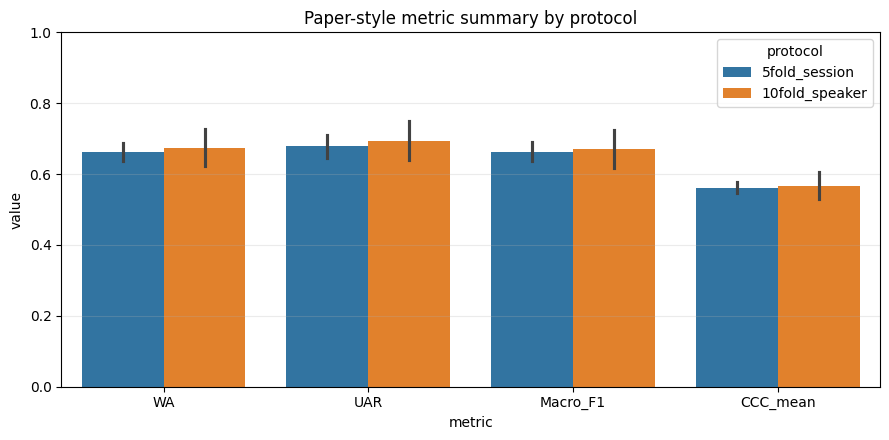

Saved: /kaggle/working/output_03c_transcript_text_branch/figures/paper_style_metric_summary.png


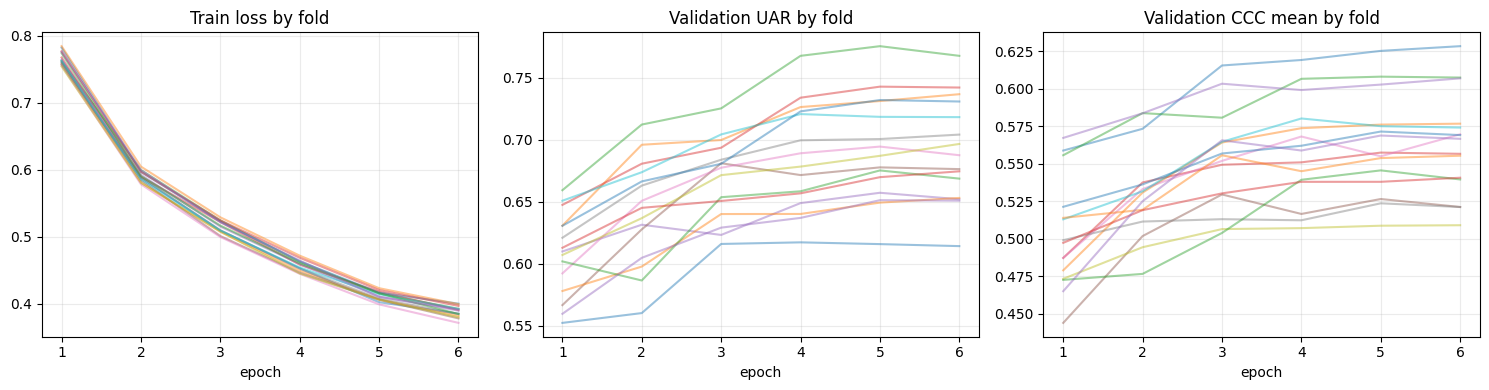

Saved: /kaggle/working/output_03c_transcript_text_branch/figures/training_curves_by_fold.png


,relative_path,folder,bytes
0,figures/paper_style_metric_summary.png,figures,40169
1,figures/training_curves_by_fold.png,figures,260818
2,figures/transcript_dataset_overview.png,figures,69222
3,fusion_features/10fold_speaker_fold_10_test_Se...,fusion_features,913988
4,fusion_features/10fold_speaker_fold_10_test_Se...,fusion_features,6052721
...,...,...,...
140,reports/5fold_session_fold_5_test_Ses05_val_Se...,reports,279922
141,reports/5fold_session_fold_5_test_Ses05_val_Se...,reports,95204
142,reports/paper_reference_comparison.csv,reports,789
143,reports/paper_style_results.csv,reports,414


In [13]:
# AUTO-03ABC-PAPER-RESULTS
def _format_mean_std(df, metric_cols):
    rows = []
    for protocol, group in df.groupby("protocol"):
        row = {"Protocol": protocol, "Folds": int(group["fold"].nunique())}
        for metric in metric_cols:
            if metric in group.columns:
                scale = 100.0 if metric in ["WA", "UAR", "Macro_F1", "Weighted_F1"] else 1.0
                row[metric] = f"{group[metric].mean() * scale:.2f} ± {group[metric].std(ddof=0) * scale:.2f}"
        rows.append(row)
    return pd.DataFrame(rows)

if "results_df" in globals() and len(results_df) > 0:
    metric_cols = ["WA", "UAR", "Macro_F1", "Weighted_F1", "CCC_valence", "CCC_arousal", "CCC_dominance", "CCC_mean", "MAE_mean", "RMSE_mean"]
    paper_style = _format_mean_std(results_df, metric_cols)
    paper_style_path = REPORT_DIR / "paper_style_results.csv"
    paper_style.to_csv(paper_style_path, index=False, encoding="utf-8-sig")
    display(paper_style)

    reference_rows = [
        {
            "Model": "Wav2Vec2 P-TAPT (Chen & Rudnicky, 2021)",
            "Modality": "audio",
            "Split": "IEMOCAP session-level",
            "WA/WAR": "",
            "UAR/UA": "74.30",
            "CCC V": "",
            "CCC A": "",
            "CCC D": "",
            "Note": "Pretrained speech fine-tuning reference for 03A",
        },
        {
            "Model": "Ispas et al. 2024 multi-task multi-modal",
            "Modality": "audio + transcript",
            "Split": "10-fold speaker",
            "WA/WAR": "74.69",
            "UAR/UA": "74.68",
            "CCC V": "0.738",
            "CCC A": "0.685",
            "CCC D": "",
            "Note": "Reference for multi-task + bridge/cross-attention",
        },
        {
            "Model": "Proposed notebook branch",
            "Modality": config.get("notebook", "current branch") if "config" in globals() else "current branch",
            "Split": "5-fold + 10-fold",
            "WA/WAR": "; ".join([f"{r['Protocol']}: {r.get('WA', '')}" for _, r in paper_style.iterrows()]),
            "UAR/UA": "; ".join([f"{r['Protocol']}: {r.get('UAR', '')}" for _, r in paper_style.iterrows()]),
            "CCC V": "; ".join([f"{r['Protocol']}: {r.get('CCC_valence', '')}" for _, r in paper_style.iterrows()]),
            "CCC A": "; ".join([f"{r['Protocol']}: {r.get('CCC_arousal', '')}" for _, r in paper_style.iterrows()]),
            "CCC D": "; ".join([f"{r['Protocol']}: {r.get('CCC_dominance', '')}" for _, r in paper_style.iterrows()]),
            "Note": "Direct result from this notebook; compare carefully because modality/split can differ from papers",
        },
    ]
    comparison_df = pd.DataFrame(reference_rows)
    comparison_path = REPORT_DIR / "paper_reference_comparison.csv"
    comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")
    display(comparison_df)

    if "plt" in globals() and plt is not None:
        plot_metrics = [m for m in ["WA", "UAR", "Macro_F1", "CCC_mean"] if m in results_df.columns]
        melted = results_df.melt(id_vars=["protocol", "fold"], value_vars=plot_metrics, var_name="metric", value_name="value")
        fig, ax = plt.subplots(figsize=(9, 4.5))
        if "sns" in globals() and sns is not None:
            try:
                sns.barplot(data=melted, x="metric", y="value", hue="protocol", errorbar="sd", ax=ax)
            except TypeError:
                sns.barplot(data=melted, x="metric", y="value", hue="protocol", ci="sd", ax=ax)
        else:
            for i, metric in enumerate(plot_metrics):
                vals = [results_df.loc[results_df["protocol"] == p, metric].mean() for p in results_df["protocol"].unique()]
                ax.bar([i + j * 0.25 for j in range(len(vals))], vals, width=0.22)
            ax.set_xticks(range(len(plot_metrics)), plot_metrics)
        ax.set_title("Paper-style metric summary by protocol")
        ax.set_ylim(0, 1.0)
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        fig_path = FIGURE_DIR / "paper_style_metric_summary.png"
        fig.savefig(fig_path, dpi=160)
        plt.show()
        print("Saved:", fig_path)

        history_files = sorted(REPORT_DIR.glob("*_history.csv"))
        if history_files:
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            for hp in history_files:
                h = pd.read_csv(hp)
                label = hp.stem.replace("_history", "")
                if "epoch" in h.columns:
                    if "train_loss" in h.columns:
                        axes[0].plot(h["epoch"], h["train_loss"], alpha=0.45)
                    if "val_UAR" in h.columns:
                        axes[1].plot(h["epoch"], h["val_UAR"], alpha=0.45)
                    if "val_CCC_mean" in h.columns:
                        axes[2].plot(h["epoch"], h["val_CCC_mean"], alpha=0.45)
            axes[0].set_title("Train loss by fold")
            axes[1].set_title("Validation UAR by fold")
            axes[2].set_title("Validation CCC mean by fold")
            for ax in axes:
                ax.set_xlabel("epoch")
                ax.grid(alpha=0.25)
            fig.tight_layout()
            fig_path = FIGURE_DIR / "training_curves_by_fold.png"
            fig.savefig(fig_path, dpi=160)
            plt.show()
            print("Saved:", fig_path)

    manifest_rows = []
    for path in sorted(OUTPUT_DIR.rglob("*")):
        if path.is_file():
            relative = path.relative_to(OUTPUT_DIR)
            manifest_rows.append({
                "relative_path": str(relative).replace("\\", "/"),
                "folder": relative.parts[0] if relative.parts else "",
                "bytes": int(path.stat().st_size),
            })
    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(REPORT_DIR / "output_manifest.csv", index=False, encoding="utf-8-sig")
    display(manifest_df)
else:
    print("Chưa có results_df. Hãy chạy cell train trước khi tạo bảng paper-style.")

In [14]:
config = {
    "notebook": "03C transcript pretrained text multi-task branch",
    "text_model": TEXT_MODEL_NAME,
    "max_length": MAX_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr_backbone": LR_BACKBONE,
    "lr_head": LR_HEAD,
    "dropout": DROPOUT,
    "run_protocols": RUN_PROTOCOLS,
    "max_folds": MAX_FOLDS,
    "architecture": {
        "backbone": "pretrained text transformer",
        "pooling": "CLS + masked mean + attentive pooling",
        "heads": "emotion classification + VAD regression",
        "output": "fusion_features for notebook 04",
    },
}
(OUTPUT_DIR / "03c_text_branch_run_config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
zip_output(OUTPUT_DIR)

Saved zip: /kaggle/working/output_03c_transcript_text_branch.zip


PosixPath('/kaggle/working/output_03c_transcript_text_branch.zip')

In [ ]:
import time
from datetime import timedelta

RUN_HOURS = 3
TOTAL_SECONDS = RUN_HOURS * 60 * 60

start_time = time.time()

print("🚀 Bắt đầu chạy trong 3 tiếng...")

try:
    for hour in range(1, RUN_HOURS + 1):
        time.sleep(60 * 60)  # Chờ 1 tiếng

        elapsed = int(time.time() - start_time)
        remaining = max(0, TOTAL_SECONDS - elapsed)

        print(
            f"⏱ Đã chạy: {timedelta(seconds=elapsed)}"
            f" | Còn lại: {timedelta(seconds=remaining)}"
        )

except KeyboardInterrupt:
    print("\n⛔ Đã dừng thủ công.")

print("✅ Hoàn thành 3 tiếng.")